In [1]:
# # To unzip
# from zipfile import ZipFile
# file_name = "/content/drive/MyDrive/Colab Notebooks/Dataset/AWA2_artefact1.zip"
# with ZipFile(file_name, 'r') as zip:
#   zip.extractall()
#   print(f'done! {file_name}')

In [2]:
# !pip install split-folders

# import splitfolders
# splitfolders.ratio('set', output="data", seed=42, ratio=(0.8, 0.1, 0.1))

In [3]:
# !pip install gensim -q
# !pip install tqdm -q
# # For Jupyter notebook support
# !pip install "tqdm[notebook]" -q

In [4]:
import os
import re
import numpy as np
import pandas as pd
import urllib.request
import time
from functools import wraps
import glob
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

# !pip install gensim
from gensim.utils import simple_preprocess

import builtins
zip = builtins.zip   # restore the real zip function

import warnings
warnings.filterwarnings('ignore')


In [6]:
class_labels = sorted([path.split('\\')[-1] for path in glob.glob(os.path.join('awa_data', 'test', '*'))])
lables_dict = {k:v for k, v in enumerate(class_labels) }
class_dict = {v: k for k, v in lables_dict.items()}
print(class_labels)
print(lables_dict)
print(class_dict)

['bear', 'blue_whale', 'bobcat', 'cow', 'dolphin', 'gorilla', 'killer_whale', 'lion', 'monkey', 'mouse', 'ox', 'rabbit', 'rhinoceros', 'siamese_cat', 'skunk', 'squirrel', 'tiger', 'walrus']
{0: 'bear', 1: 'blue_whale', 2: 'bobcat', 3: 'cow', 4: 'dolphin', 5: 'gorilla', 6: 'killer_whale', 7: 'lion', 8: 'monkey', 9: 'mouse', 10: 'ox', 11: 'rabbit', 12: 'rhinoceros', 13: 'siamese_cat', 14: 'skunk', 15: 'squirrel', 16: 'tiger', 17: 'walrus'}
{'bear': 0, 'blue_whale': 1, 'bobcat': 2, 'cow': 3, 'dolphin': 4, 'gorilla': 5, 'killer_whale': 6, 'lion': 7, 'monkey': 8, 'mouse': 9, 'ox': 10, 'rabbit': 11, 'rhinoceros': 12, 'siamese_cat': 13, 'skunk': 14, 'squirrel': 15, 'tiger': 16, 'walrus': 17}


# GloVe embeddings

In [13]:

def timer(func):
    """Simple decorator that prints execution time"""
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"{func.__name__} took {end - start:.4f} seconds")
        return result
    return wrapper

# Load GloVe embeddings
def load_glove_embeddings(file_path):
    embeddings_index = {}
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

# Convert sentences to embeddings
def sentence_to_embedding(sentence, embeddings_index):
    words = simple_preprocess(sentence)
    valid_words = [embeddings_index[word] for word in words if word in embeddings_index]
    if valid_words:
        return np.mean(valid_words, axis=0)
    else:
        return np.zeros(300) # Using 50d GloVe embeddings

@timer
def get_glove_embeddings(custom_sentences: list,
                         glove_embeddings: str = r"glove.6B\glove.6B.300d.txt") -> pd.DataFrame:
    '''
    Convert sentences to GloVe embeddings.

    Args:
        custom_sentences: List of sentences to embed
        glove_embeddings_path: Path to GloVe embeddings file

    Returns:
        DataFrame with sentence embeddings
    '''
    # Using 300d GloVe embeddings
    embeddings_index = load_glove_embeddings(glove_embeddings)

    # Your embeddings code here (commented out for example)
    sentence_embeddings = np.array([sentence_to_embedding(sentence,
                                                        embeddings_index)
                                  for sentence in custom_sentences])

    # For demonstration, creating dummy embeddings
    np.random.seed(42)
    sentence_embeddings = np.random.randn(len(custom_sentences), 300)

    df = pd.DataFrame(sentence_embeddings)
    df['custom_sentences'] = custom_sentences
    return df

In [14]:
GloVe_df = get_glove_embeddings(class_labels)
display(GloVe_df.head())

# save df
GloVe_df.to_csv('awa2_glove_embeddings.csv', index=False)

get_glove_embeddings took 30.6123 seconds


,0,1,2,3,4,5,6,7,8,9,...,291,292,293,294,295,296,297,298,299,custom_sentences
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,...,-0.493001,-0.589365,0.849602,0.357015,-0.692910,0.899600,0.307300,0.812862,0.629629,bear
1,-0.828995,-0.560181,0.747294,0.610370,-0.020902,0.117327,1.277665,-0.591571,0.547097,-0.202193,...,-0.477657,0.478980,0.333662,1.037540,-0.510016,-0.269875,-0.978764,-0.444293,0.377300,blue_whale
2,0.756989,-0.922165,0.869606,1.355638,0.413435,1.876796,-0.773789,-1.244655,-1.778720,1.496044,...,0.507274,1.066675,1.169296,1.382159,0.648710,-0.167118,0.146714,1.206509,-0.816936,bobcat
3,0.368673,-0.393339,0.028745,1.278452,0.191099,0.046437,-1.359856,0.746254,0.645484,2.163255,...,-1.334025,-0.601368,0.319782,-1.592994,0.440475,-0.019638,0.552490,0.223914,1.364140,cow
4,0.125225,-0.429406,0.122298,0.543298,0.048860,0.040592,-0.701992,-0.662901,-1.402605,1.749577,...,2.558199,-0.564248,0.184551,1.542110,2.006093,2.061504,1.208366,1.024063,0.592527,dolphin


# Sentence Transformers

In [21]:
# STEP 1: Install required package (run this once)
# !pip install sentence-transformers

# STEP 2: Import and use the model
from sentence_transformers import SentenceTransformer

# Load the model (this downloads it first time)
print("Loading model...")
model = SentenceTransformer('all-mpnet-base-v2')
print("Model loaded!")

Loading model...
✅ Model loaded!


In [22]:
# Your class names
animals = ['bear', 'blue_whale', 'bobcat', 'cow', 'dolphin', 
           'gorilla', 'killer_whale', 'lion', 'monkey', 'mouse', 
           'ox', 'rabbit', 'rhinoceros', 'siamese_cat', 'skunk', 
           'squirrel', 'tiger', 'walrus']

print(f"\nNumber of classes: {len(animals)}")

# ============================================
# METHOD 1: Get embeddings for class names
# ============================================
print("\n" + "="*50)
print("METHOD 1: Embeddings from class names")
print("="*50)

# Create embeddings (this is the main part!)
animal_embeddings = model.encode(animals)

print(f"Embedding shape: {animal_embeddings.shape}")
print(f"Each animal has {animal_embeddings.shape[1]} numbers")
print(f"\nFirst animal '{animals[0]}' embedding (first 10 numbers):")
print(animal_embeddings[0][:10])



Number of classes: 18

METHOD 1: Embeddings from class names
Embedding shape: (18, 768)
Each animal has 768 numbers

First animal 'bear' embedding (first 10 numbers):
[ 0.02635898  0.04302888  0.00992954 -0.05588572  0.01488064 -0.00435062
 -0.03483595  0.00673913  0.03940684 -0.0511499 ]


In [26]:
# # ============================================
# # METHOD 2: Get embeddings from sentences
# # ============================================
# print("\n" + "="*50)
# print("METHOD 2: Embeddings from sentences")
# print("="*50)

# sentences = [
#     "A tiger is a large wild cat with stripes",
#     "The blue whale is the largest animal on Earth",
#     "Pandas eat bamboo and are black and white",
#     "Elephants have long trunks and big ears"
# ]

# sentence_embeddings = model.encode(sentences)
# print(f"Sentences: {len(sentences)}")
# print(f"Embedding shape: {sentence_embeddings.shape}")
# print(f"Each sentence has {sentence_embeddings.shape[1]} numbers")


In [27]:
# ============================================
# METHOD 3: Compare similarities
# ============================================
print("\n" + "="*50)
print("METHOD 3: Find similar animals")
print("="*50)

from sklearn.metrics.pairwise import cosine_similarity

# Get embedding for 'tiger'
tiger_idx = animals.index('tiger')
tiger_emb = animal_embeddings[tiger_idx]

# Compare with all animals
similarities = cosine_similarity([tiger_emb], animal_embeddings)[0]

# Get top 5 most similar to tiger
top_indices = np.argsort(similarities)[-6:][::-1]  # Get top 5 + tiger itself

print("Animals most similar to TIGER:")
for idx in top_indices:
    if animals[idx] != 'tiger':  # Skip tiger itself
        print(f"  {animals[idx]}: {similarities[idx]:.3f}")


METHOD 3: Find similar animals
Animals most similar to TIGER:
  lion: 0.667
  bear: 0.532
  rhinoceros: 0.518
  monkey: 0.518
  squirrel: 0.496


In [28]:
# ============================================
# METHOD 4: Save to CSV (what you need!)
# ============================================
print("\n" + "="*50)
print("METHOD 4: Save embeddings to CSV")
print("="*50)

# Create a dataframe
data = []
for i, animal in enumerate(animals):
    row = {'animal': animal, 'index': i}
    # Add all 768 embedding values
    for j, val in enumerate(animal_embeddings[i]):
        row[f'dim_{j}'] = val
    data.append(row)

df = pd.DataFrame(data)
df.to_csv('animal_embeddings_mpnet.csv', index=False)
print(f"Saved to 'animal_embeddings_mpnet.csv'")
print(f"   Shape: {df.shape} (18 rows × {df.shape[1]} columns)")
print(f"   First 5 columns: {list(df.columns)[:5]}")



METHOD 4: Save embeddings to CSV
✅ Saved to 'animal_embeddings_mpnet.csv'
   Shape: (18, 770) (18 rows × 770 columns)
   First 5 columns: ['animal', 'index', 'dim_0', 'dim_1', 'dim_2']


In [29]:
# ============================================
# METHOD 5: Load and use the saved CSV
# ============================================
print("\n" + "="*50)
print("METHOD 5: Load embeddings from CSV")
print("="*50)

# Load the CSV
loaded_df = pd.read_csv('animal_embeddings_mpnet.csv')
loaded_animals = loaded_df['animal'].tolist()

# Get embedding columns (all dim_0 to dim_767)
dim_cols = [col for col in loaded_df.columns if col.startswith('dim_')]
loaded_embeddings = loaded_df[dim_cols].values

print(f"Loaded {len(loaded_animals)} animals")
print(f"Embeddings shape: {loaded_embeddings.shape}")
print(f"First animal: {loaded_animals[0]}")
print(f"Its embedding (first 5 numbers): {loaded_embeddings[0][:5]}")


METHOD 5: Load embeddings from CSV
Loaded 18 animals
Embeddings shape: (18, 768)
First animal: bear
Its embedding (first 5 numbers): [ 0.02635898  0.04302888  0.00992954 -0.05588572  0.01488064]


# VGG16 - Feature Extraction + Label Collection

In [17]:
# Feature Extractor
def build_feature_extractor():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    return base_model

# Create the feature extractor
feature_extractor = build_feature_extractor()
# feature_extractor.summary()

# variables - dataset path
train_data_path = os.path.join('awa_data', 'train') # /content/train
val_data_path = os.path.join('awa_data', 'test')
test_data_path = os.path.join('awa_data', 'test')

# Load and Preprocess Images
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = datagen.flow_from_directory(train_data_path,
                                         target_size = (224, 224),
                                         batch_size = 16,
                                         class_mode = 'categorical')
val_data = datagen.flow_from_directory(val_data_path,
                                       target_size = (224, 224),
                                       batch_size = 16,
                                       class_mode = 'categorical')
test_data = datagen.flow_from_directory(test_data_path,
                                        target_size = (224, 224),
                                        batch_size = 16,
                                        class_mode = 'categorical')

X_train_features = []
y_train_labels = []

# Loop over train_data batches
for images, labels in tqdm(train_data, desc="Processing images"):
    features = feature_extractor.predict(images, verbose=0)
    X_train_features.append(features)
    y_train_labels.append(np.argmax(labels, axis=1))  # categorical class_mode

    # break early if too large
    if len(X_train_features) * train_data.batch_size > 10000:
        break

# Stack all batches into arrays
X_train_features = np.vstack(X_train_features)
y_train_labels = np.concatenate(y_train_labels)

Found 720 images belonging to 18 classes.
Found 144 images belonging to 18 classes.
Found 144 images belonging to 18 classes.


Processing images: 625it [37:47,  3.63s/it]                                                                                               


In [18]:
# create dataframe
data = pd.DataFrame(X_train_features)
data['lable'] = y_train_labels
display(data.head())

# save df
data.to_csv('VGG16_based_feature.csv', index=False)

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,lable
0,1.020250,0.000000,0.000000,0.000000,1.168013,7.367301,1.004861,0.791434,9.275630,0.338919,...,0.000000,2.149533,0.216370,0.356437,0.000000,0.143631,0.000000,0.000000,6.553646,14
1,1.706964,0.000000,3.492385,0.678951,3.256159,0.716151,0.662544,0.116414,0.308125,0.000000,...,0.194556,0.359026,0.112840,0.334527,2.788661,0.160284,1.025115,0.730634,0.000000,0
2,5.407966,0.000000,10.695903,0.073941,2.705657,0.861446,0.000000,8.283251,0.209533,0.116279,...,0.000000,3.754162,3.297244,0.148317,0.291433,0.000000,1.643402,0.196487,0.071475,7
3,1.699940,0.193659,23.095737,0.000000,16.712078,1.283739,0.565709,0.077394,13.662940,0.078557,...,0.315427,0.186696,26.457180,0.329820,0.158941,0.000000,0.000000,1.068729,18.351011,3
4,0.664383,0.000000,6.047741,1.866505,10.623646,3.755624,0.211040,1.203640,0.000000,2.010990,...,0.586089,1.694329,2.494780,7.068923,0.000000,2.368330,0.023520,0.418254,0.000000,15


In [37]:
vgg16_fetures_df = pd.read_csv('VGG16_based_feature.csv')
embeddings_mpnet_df = pd.read_csv('animal_embeddings_mpnet.csv')
embeddings_mpnet_df = embeddings_mpnet_df.rename(columns={'index': 'lable'})

display(vgg16_fetures_df.head())
print('='*50)
display(embeddings_mpnet_df.head())
print('='*50)

# def find_num(text):
#     return next((num for animal, num in class_dict.items() if animal in str(text).lower()), -1)
# df['lable'] = df['index'].apply(find_num)

concat_df = pd.merge(vgg16_fetures_df, embeddings_mpnet_df, on='lable', how='left')
display(concat_df.head())
print('='*50)

# save concat data
concat_df.to_csv('concat_df.csv', index=False)

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,lable
0,1.020250,0.000000,0.000000,0.000000,1.168013,7.367301,1.004861,0.791434,9.275630,0.338919,...,0.000000,2.149533,0.216370,0.356437,0.000000,0.143631,0.000000,0.000000,6.553646,14
1,1.706964,0.000000,3.492385,0.678951,3.256159,0.716151,0.662544,0.116414,0.308125,0.000000,...,0.194556,0.359026,0.112840,0.334527,2.788661,0.160284,1.025116,0.730634,0.000000,0
2,5.407966,0.000000,10.695903,0.073941,2.705657,0.861446,0.000000,8.283251,0.209533,0.116279,...,0.000000,3.754162,3.297244,0.148317,0.291433,0.000000,1.643402,0.196487,0.071475,7
3,1.699940,0.193659,23.095737,0.000000,16.712078,1.283739,0.565709,0.077394,13.662940,0.078557,...,0.315427,0.186696,26.457180,0.329820,0.158941,0.000000,0.000000,1.068729,18.351011,3
4,0.664383,0.000000,6.047741,1.866505,10.623646,3.755624,0.211040,1.203640,0.000000,2.010990,...,0.586089,1.694329,2.494780,7.068923,0.000000,2.368330,0.023520,0.418254,0.000000,15


,animal,lable,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,...,dim_758,dim_759,dim_760,dim_761,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767
0,bear,0,0.026359,0.043029,0.009930,-0.055886,0.014881,-0.004351,-0.034836,0.006739,...,-0.004714,0.000515,0.004260,0.013391,-0.013616,-0.042900,-0.001769,0.057232,-0.009386,0.008419
1,blue_whale,1,0.059633,0.009495,0.020639,-0.045618,-0.021704,0.039786,0.011971,0.021878,...,0.012943,0.012590,0.034477,0.029847,-0.022521,-0.026751,-0.004802,0.037020,-0.017318,0.005681
2,bobcat,2,0.039309,0.052171,0.011086,-0.067435,0.022979,0.009126,-0.062299,0.024596,...,-0.031318,0.048596,0.076484,-0.012110,0.012987,-0.095912,-0.015674,0.026102,0.022926,-0.006266
3,cow,3,0.011990,0.090183,0.017480,-0.026787,0.001731,0.018055,-0.017418,0.032862,...,-0.032978,0.021480,0.034851,-0.002203,-0.011200,0.059751,-0.044079,0.012377,-0.026457,-0.025053
4,dolphin,4,0.007503,0.073541,-0.017334,-0.087415,-0.000507,0.006991,-0.010800,0.058015,...,-0.015108,-0.019974,0.071521,0.016802,-0.032925,0.138942,-0.028268,0.041424,0.003328,-0.031043


,0,1,2,3,4,5,6,7,8,9,...,dim_758,dim_759,dim_760,dim_761,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767
0,1.020250,0.000000,0.000000,0.000000,1.168013,7.367301,1.004861,0.791434,9.275630,0.338919,...,0.030008,-0.010556,-0.044228,-0.001061,-0.026858,0.058214,-0.037791,0.026363,0.027595,0.008479
1,1.706964,0.000000,3.492385,0.678951,3.256159,0.716151,0.662544,0.116414,0.308125,0.000000,...,-0.004714,0.000515,0.004260,0.013391,-0.013616,-0.042900,-0.001769,0.057232,-0.009386,0.008419
2,5.407966,0.000000,10.695903,0.073941,2.705657,0.861446,0.000000,8.283251,0.209533,0.116279,...,-0.014348,-0.020995,0.064975,0.006016,-0.018707,0.041329,-0.008640,0.005553,-0.013681,-0.012157
3,1.699940,0.193659,23.095737,0.000000,16.712078,1.283739,0.565709,0.077394,13.662940,0.078557,...,-0.032978,0.021480,0.034851,-0.002203,-0.011200,0.059751,-0.044079,0.012377,-0.026457,-0.025053
4,0.664383,0.000000,6.047741,1.866505,10.623646,3.755624,0.211040,1.203640,0.000000,2.010990,...,-0.012459,0.000473,-0.004981,-0.020739,-0.001565,0.092476,-0.033560,0.003882,0.013299,-0.014664


In [57]:
# dim_df = concat_df.loc[:, concat_df.columns.str.startswith('dim_')]
# dim_df.head()

In [58]:
# for i in concat_df.columns:
#     print(i)
    
# [i for i in range(512)]

# concat_df.columns.str.startswith('dim_')

In [23]:
concat_df = pd.read_csv('concat_df.csv')
# concat_df.columns[512:]

cols = [str(i) for i in range(512)] + ['lable'] # , 'animal'
train_df = concat_df.loc[:, cols]
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,lable
0,1.020250,0.000000,0.000000,0.000000,1.168013,7.367301,1.004861,0.791434,9.275630,0.338919,...,0.000000,2.149533,0.216370,0.356437,0.000000,0.143631,0.000000,0.000000,6.553646,14
1,1.706964,0.000000,3.492385,0.678951,3.256159,0.716151,0.662544,0.116414,0.308125,0.000000,...,0.194556,0.359026,0.112840,0.334527,2.788661,0.160284,1.025116,0.730634,0.000000,0
2,5.407966,0.000000,10.695903,0.073941,2.705657,0.861446,0.000000,8.283251,0.209533,0.116279,...,0.000000,3.754162,3.297244,0.148317,0.291433,0.000000,1.643402,0.196487,0.071475,7
3,1.699940,0.193659,23.095737,0.000000,16.712078,1.283739,0.565709,0.077394,13.662940,0.078557,...,0.315427,0.186696,26.457180,0.329820,0.158941,0.000000,0.000000,1.068729,18.351011,3
4,0.664383,0.000000,6.047741,1.866505,10.623646,3.755624,0.211040,1.203640,0.000000,2.010990,...,0.586089,1.694329,2.494780,7.068923,0.000000,2.368330,0.023520,0.418254,0.000000,15


# InfoGAN for Tabular Data

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [25]:
# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================

# def load_and_prepare_data(csv_file, target_column):
# def load_and_prepare_data(df):
def load_and_prepare_data(df, target_column):
    """
    Load CSV and separate features
    """
    # Load data
    # df = pd.read_csv(csv_file)
    
    # Separate features (X) and target (y)
    X = df.drop(columns=[target_column]).values
    y = df[target_column].values
    
#     X = df.loc[:, [str(i) for i in range(512)]]
#     y = df.loc[:, concat_df.columns.str.startswith('dim_')]
    
    print(f" Loaded {X.shape[0]} samples with {X.shape[1]} features")
    print(f" Target classes: {len(np.unique(y))}")
    
    return X, y

# X, y = load_and_prepare_data(concat_df)
X, y = load_and_prepare_data(train_df, 'lable')



# def normalize_data(X_train, X_test=None):
#     """
#     Normalize features to [-1, 1] range for GAN
#     """
#     scaler = StandardScaler()
#     X_train_norm = scaler.fit_transform(X_train)
    
#     # Clip to [-1, 1] (tanh output range)
#     X_train_norm = np.clip(X_train_norm, -1, 1)
    
#     if X_test is not None:
#         X_test_norm = scaler.transform(X_test)
#         X_test_norm = np.clip(X_test_norm, -1, 1)
#         return X_train_norm, X_test_norm, scaler
    
#     return X_train_norm, scaler

 Loaded 10016 samples with 512 features
 Target classes: 18


Creating sample data for demo...
INFOGAN FOR TABULAR DATA
Training samples: 8012, Validation: 2004

🤖 Step 3: Creating InfoGAN...

🎯 Step 4: Training InfoGAN...
🚀 Training InfoGAN...
Epoch 10/100 | D: 0.0234 | G: 4.5937 | Q: 3.3005
Epoch 20/100 | D: 0.0026 | G: 7.4400 | Q: 3.3320
Epoch 30/100 | D: 0.0011 | G: 9.6533 | Q: 3.3835
Epoch 40/100 | D: 0.0003 | G: 10.6594 | Q: 3.3427
Epoch 50/100 | D: 0.0045 | G: 11.3300 | Q: 3.3361
Epoch 60/100 | D: 0.0002 | G: 11.6246 | Q: 3.3345
Epoch 70/100 | D: 0.0001 | G: 12.2495 | Q: 3.3113
Epoch 80/100 | D: 0.0002 | G: 11.3203 | Q: 3.3493
Epoch 90/100 | D: 0.0004 | G: 11.7909 | Q: 3.3194
Epoch 100/100 | D: 0.0008 | G: 11.8417 | Q: 3.3367

✨ Step 5: Generating new samples...

📊 Step 6: Evaluating...

 Evaluation Results:
----------------------------------------
Mean difference: 2.3995
Std difference: 3.6824
Correlation: 0.3501

 Step 7: Visualizing...
[[ 1.0202501   0.          0.         ...  0.          0.
   6.553646  ]
 [ 1.7069637   0.          3.

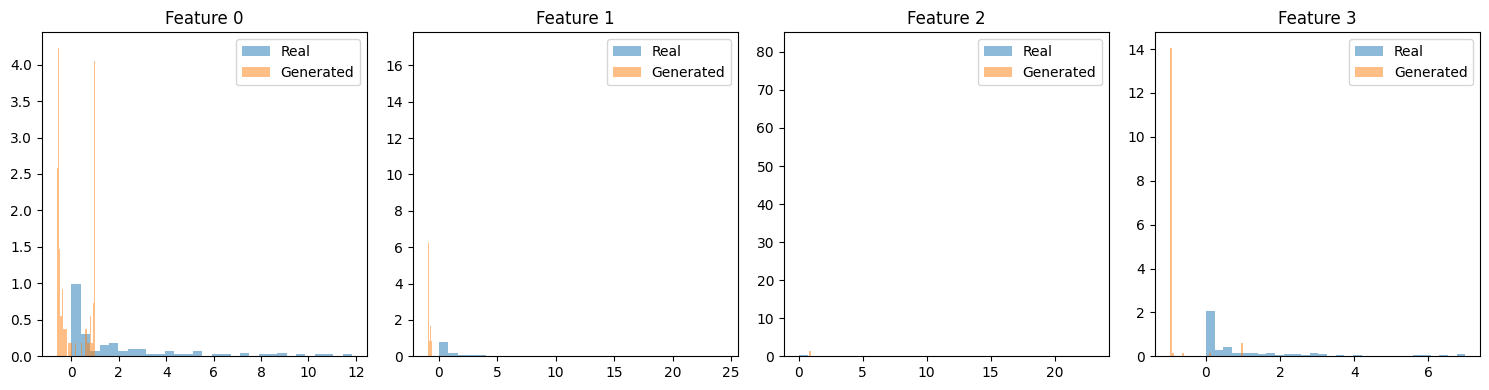


 Step 8: Saving models...


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


 Models saved to infogan_model_*.h5

 InfoGAN training complete!


In [26]:
# ============================================
# PART 2: BUILD INFOGAN MODELS
# ============================================

def build_generator(latent_dim, code_dim, data_dim):
    """
    Build generator: noise + code -> fake data
    """
    # Inputs
    noise_input = layers.Input(shape=(latent_dim,), name='noise')
    code_input = layers.Input(shape=(code_dim,), name='code')
    
    # Combine
    combined = layers.Concatenate()([noise_input, code_input])
    
    # Hidden layers
    x = layers.Dense(128, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Output layer (tanh for [-1, 1] range)
    output = layers.Dense(data_dim, activation='tanh')(x)
    
    model = Model([noise_input, code_input], output, name='Generator')
    return model

def build_discriminator(data_dim):
    """
    Build discriminator: real/fake classifier
    """
    input_layer = layers.Input(shape=(data_dim,))
    
    x = layers.Dense(128, activation='leaky_relu')(input_layer)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='leaky_relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='leaky_relu')(x)
    
    # Output: probability of being real
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = Model(input_layer, output, name='Discriminator')
    return model

def build_code_network(data_dim, code_dim):
    """
    Build code network: data -> predicted code (for InfoGAN)
    """
    input_layer = layers.Input(shape=(data_dim,))
    
    x = layers.Dense(128, activation='relu')(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    
    # Output: predicted latent code
    output = layers.Dense(code_dim, activation='linear')(x)
    
    model = Model(input_layer, output, name='CodeNetwork')
    return model

# ============================================
# PART 3: INFOGAN TRAINER CLASS
# ============================================

class InfoGAN:
    def __init__(self, latent_dim, code_dim, data_dim):
        self.latent_dim = latent_dim
        self.code_dim = code_dim
        self.data_dim = data_dim
        
        # Build models
        self.generator = build_generator(latent_dim, code_dim, data_dim)
        self.discriminator = build_discriminator(data_dim)
        self.code_network = build_code_network(data_dim, code_dim)
        
        # Optimizers
        self.g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
        self.d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
        self.q_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
        
        # Loss functions
        self.binary_loss = tf.keras.losses.BinaryCrossentropy()
        self.mse_loss = tf.keras.losses.MeanSquaredError()
        
        # History
        self.history = {'d_loss': [], 'g_loss': [], 'q_loss': []}
    
    @tf.function
    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        
        # Generate random noise and codes
        noise = tf.random.normal([batch_size, self.latent_dim])
        code = tf.random.uniform([batch_size, self.code_dim], -1, 1)  # Uniform in [-1, 1]
        
        # Train Discriminator
        with tf.GradientTape() as d_tape:
            # Generate fake data
            fake_data = self.generator([noise, code], training=True)
            
            # Discriminator outputs
            real_output = self.discriminator(real_data, training=True)
            fake_output = self.discriminator(fake_data, training=True)
            
            # Losses
            d_real_loss = self.binary_loss(tf.ones_like(real_output), real_output)
            d_fake_loss = self.binary_loss(tf.zeros_like(fake_output), fake_output)
            d_loss = d_real_loss + d_fake_loss
        
        # Update discriminator
        d_gradients = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(d_gradients, self.discriminator.trainable_variables))
        
        # Train Generator + Code Network
        with tf.GradientTape() as g_tape, tf.GradientTape() as q_tape:
            # Generate new fake data
            noise = tf.random.normal([batch_size, self.latent_dim])
            code = tf.random.uniform([batch_size, self.code_dim], -1, 1)
            fake_data = self.generator([noise, code], training=True)
            
            # Discriminator output on fake data
            fake_output = self.discriminator(fake_data, training=True)
            
            # Generator loss (want discriminator to think fake is real)
            g_loss = self.binary_loss(tf.ones_like(fake_output), fake_output)
            
            # Code network prediction and loss
            code_pred = self.code_network(fake_data, training=True)
            q_loss = self.mse_loss(code, code_pred) * 10  # Scale factor for code loss
        
        # Update generator
        g_gradients = g_tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(g_gradients, self.generator.trainable_variables))
        
        # Update code network
        q_gradients = q_tape.gradient(q_loss, self.code_network.trainable_variables)
        self.q_optimizer.apply_gradients(zip(q_gradients, self.code_network.trainable_variables))
        
        return d_loss, g_loss, q_loss
    
    def train(self, data, epochs=100, batch_size=32):
        """Train the InfoGAN"""
        dataset = tf.data.Dataset.from_tensor_slices(data)
        dataset = dataset.shuffle(buffer_size=len(data))
        dataset = dataset.batch(batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        
        print("🚀 Training InfoGAN...")
        for epoch in range(epochs):
            epoch_d_loss = []
            epoch_g_loss = []
            epoch_q_loss = []
            
            for batch in dataset:
                d_loss, g_loss, q_loss = self.train_step(batch)
                epoch_d_loss.append(d_loss.numpy())
                epoch_g_loss.append(g_loss.numpy())
                epoch_q_loss.append(q_loss.numpy())
            
            # Store averages
            self.history['d_loss'].append(np.mean(epoch_d_loss))
            self.history['g_loss'].append(np.mean(epoch_g_loss))
            self.history['q_loss'].append(np.mean(epoch_q_loss))
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} | D: {self.history['d_loss'][-1]:.4f} | G: {self.history['g_loss'][-1]:.4f} | Q: {self.history['q_loss'][-1]:.4f}")
        
        return self
    
    def generate_samples(self, n_samples, code_values=None):
        """Generate new samples"""
        noise = tf.random.normal([n_samples, self.latent_dim])
        
        if code_values is None:
            # Random codes
            code = tf.random.uniform([n_samples, self.code_dim], -1, 1)
        else:
            # Fixed codes
            code = tf.constant(code_values, dtype=tf.float32)
            if len(code.shape) == 1:
                code = tf.tile(code[None, :], [n_samples, 1])
        
        samples = self.generator([noise, code], training=False)
        return samples.numpy()
    
    def plot_history(self):
        """Plot training history"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        axes[0].plot(self.history['d_loss'])
        axes[0].set_title('Discriminator Loss')
        axes[0].set_xlabel('Epoch')
        
        axes[1].plot(self.history['g_loss'])
        axes[1].set_title('Generator Loss')
        axes[1].set_xlabel('Epoch')
        
        axes[2].plot(self.history['q_loss'])
        axes[2].set_title('Code Network Loss')
        axes[2].set_xlabel('Epoch')
        
        plt.tight_layout()
        plt.show()
    
    def save_models(self, path):
        """Save all models"""
        self.generator.save(f"{path}_generator.h5")
        self.discriminator.save(f"{path}_discriminator.h5")
        self.code_network.save(f"{path}_code_network.h5")
        print(f" Models saved to {path}_*.h5")

# ============================================
# PART 4: EVALUATION FUNCTIONS
# ============================================

def evaluate_generated_data(real_data, generated_data):
    """
    Compare real vs generated data statistics
    """
    print("\n Evaluation Results:")
    print("-" * 40)
    
    # Mean comparison
    real_mean = np.mean(real_data, axis=0)
    gen_mean = np.mean(generated_data, axis=0)
    mean_diff = np.mean(np.abs(real_mean - gen_mean))
    print(f"Mean difference: {mean_diff:.4f}")
    
    # Std comparison
    real_std = np.std(real_data, axis=0)
    gen_std = np.std(generated_data, axis=0)
    std_diff = np.mean(np.abs(real_std - gen_std))
    print(f"Std difference: {std_diff:.4f}")
    
    # Correlation
    corr_matrix = np.corrcoef(real_mean, gen_mean)[0, 1]
    print(f"Correlation: {corr_matrix:.4f}")
    
    return {
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'correlation': corr_matrix
    }

def visualize_comparison(real_data, generated_data, feature_names=None):
    """
    Visualize real vs generated data distribution
    """
    if feature_names is None:
        feature_names = [f'Feature {i}' for i in range(min(4, real_data.shape[1]))]
    
    n_features = min(4, real_data.shape[1])
    fig, axes = plt.subplots(1, n_features, figsize=(15, 4))
    
    for i in range(n_features):
        axes[i].hist(real_data[:, i], bins=30, alpha=0.5, label='Real', density=True)
        axes[i].hist(generated_data[:, i], bins=30, alpha=0.5, label='Generated', density=True)
        axes[i].set_title(feature_names[i])
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

# ============================================
# PART 5: MAIN PIPELINE
# ============================================

# def main(csv_file, target_column, latent_dim=50, code_dim=10, epochs=100):
def main(latent_dim=50, code_dim=10, epochs=100):
    """
    Main function to run InfoGAN pipeline
    """
    print("=" * 60)
    print("INFOGAN FOR TABULAR DATA")
    print("=" * 60)
    
    # Step 1: Load data
#     print("\n Step 1: Loading data...")
#     X, y = load_and_prepare_data(csv_file, target_column)
    
    # Step 2: Normalize data
#     print("\n Step 2: Normalizing data...")
#     X_norm, scaler = normalize_data(X)
    
    # Step 3: Split data (optional)
#     X_train, X_val = train_test_split(X_norm, test_size=0.2, random_state=42)
    X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)
    print(f"Training samples: {X_train.shape[0]}, Validation: {X_val.shape[0]}")
    
    # Step 4: Create and train InfoGAN
    print("\n🤖 Step 3: Creating InfoGAN...")
    latent_dim = latent_dim  # Noise dimension
    code_dim = code_dim      # Latent code dimension (for InfoGAN)
    data_dim = X.shape[1]    # Number of features
    
    infogan = InfoGAN(latent_dim, code_dim, data_dim)
    
    print("\n🎯 Step 4: Training InfoGAN...")
    infogan.train(X_train, epochs=epochs, batch_size=32)
    
    # Step 5: Generate samples
    print("\n✨ Step 5: Generating new samples...")
    n_generate = 100 # 1000
    generated = infogan.generate_samples(n_generate)
    
    # Step 6: Inverse transform to original scale
    generated_original = np.array(generated) # scaler.inverse_transform(generated)
    
    # Step 7: Evaluate
    print("\n📊 Step 6: Evaluating...")
    # Take subset of real data for comparison
    real_subset = X[:n_generate]
    real_original = np.array(real_subset) # scaler.inverse_transform(real_subset)
    
    metrics = evaluate_generated_data(real_original, generated_original)
    
    # Step 8: Visualize
    print("\n Step 7: Visualizing...")
    feature_names = [f'Feature {i}' for i in range(data_dim)]
    print(real_original, generated_original, feature_names[:4])
    
    visualize_comparison(real_original, generated_original, feature_names[:4])
    
#     # Step 9: Plot training history
#     infogan.plot_history()
    
    # Step 10: Save models
    print("\n Step 8: Saving models...")
    infogan.save_models('infogan_model')
    
    print("\n InfoGAN training complete!")
    
    return infogan, generated_original # , scaler

# ============================================
# PART 6: EXAMPLE USAGE
# ============================================

if __name__ == "__main__":
    # Example: Generate synthetic data for testing
    print("Creating sample data for demo...")
    np.random.seed(42)
#     n_samples = 5000
#     n_features = 10
    
#     # Create synthetic dataset
#     X_demo = np.random.randn(n_samples, n_features)
#     y_demo = (X_demo[:, 0] + X_demo[:, 1] > 0).astype(int)
    
#     # Save to CSV
#     demo_df = pd.DataFrame(X_demo, columns=[f'feature_{i}' for i in range(n_features)])
#     demo_df['target'] = y_demo
#     demo_df.to_csv('demo_data.csv', index=False)
#     print(" Created demo_data.csv")
    
    # Run InfoGAN
#     , scaler
    infogan, generated = main( 
#         csv_file='demo_data.csv',
#         target_column='target',
        latent_dim=50,
        code_dim=10,
        epochs=100
    )
    
#     # Example: Generate with specific code
#     print("\n🎯 Generating samples with fixed code:")
#     fixed_code = np.array([[0.5, -0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
#     fixed_samples = infogan.generate_samples(5, fixed_code)
#     fixed_samples_orig = scaler.inverse_transform(fixed_samples)
#     print("Generated samples (first 5 features):")
#     print(fixed_samples_orig[:, :5])

In [10]:
import numpy as np
import tensorflow as tf
import pandas as pd

def load_infogan_for_inference(model_path='infogan_model'):
    """
    Load trained InfoGAN models for real-time generation
    """
    print("🔄 Loading InfoGAN models...")
    
    # Load the generator (main model for generation)
    generator = tf.keras.models.load_model(f"{model_path}_generator.h5")
    
    # Load the code network (optional - for encoding real data to codes)
    try:
        code_network = tf.keras.models.load_model(f"{model_path}_code_network.h5")
        print("✅ Code network loaded")
    except:
        code_network = None
        print("⚠️ Code network not found, continuing without it")
    
    print("✅ Generator loaded successfully!")
    
    return generator, code_network

# ============================================
# REAL-TIME GENERATION FUNCTIONS
# ============================================

def generate_random_samples(generator, n_samples=1, latent_dim=50, code_dim=10):
    """
    Generate random samples in real-time
    """
    # Generate random noise and codes
    noise = tf.random.normal([n_samples, latent_dim])
    code = tf.random.uniform([n_samples, code_dim], -1, 1)
    
    # Generate samples
    samples = generator([noise, code], training=False)
    
    return samples.numpy()

def generate_with_specific_code(generator, code_values, n_samples=1, latent_dim=50):
    """
    Generate samples with specific latent code (for controlled generation)
    """
    # Ensure code is 2D
    if len(code_values.shape) == 1:
        code_values = code_values.reshape(1, -1)
    
    # Repeat code for multiple samples
    if n_samples > 1 and code_values.shape[0] == 1:
        code_values = np.repeat(code_values, n_samples, axis=0)
    
    # Generate noise
    noise = tf.random.normal([n_samples, latent_dim])
    code = tf.constant(code_values, dtype=tf.float32)
    
    # Generate samples
    samples = generator([noise, code], training=False)
    
    return samples.numpy()

def generate_interpolated_samples(generator, code1, code2, n_steps=10, latent_dim=50):
    """
    Generate samples by interpolating between two latent codes
    """
    # Create interpolation weights
    alphas = np.linspace(0, 1, n_steps)
    
    all_samples = []
    for alpha in alphas:
        # Interpolate code
        interp_code = (1 - alpha) * code1 + alpha * code2
        interp_code = interp_code.reshape(1, -1)
        
        # Generate sample
        noise = tf.random.normal([1, latent_dim])
        sample = generator([noise, interp_code], training=False)
        all_samples.append(sample.numpy()[0])
    
    return np.array(all_samples)

# ============================================
# REAL-TIME PREDICTION CLASS
# ============================================

class RealTimeInfoGAN:
    """
    Easy-to-use class for real-time generation
    """
    def __init__(self, model_path='infogan_model', latent_dim=50, code_dim=10, scaler=None):
        """
        Initialize with trained model
        """
        self.latent_dim = latent_dim
        self.code_dim = code_dim
        self.scaler = scaler  # Your data scaler from training
        
        # Load models
        self.generator, self.code_network = load_infogan_for_inference(model_path)
        
        print("\n🎯 InfoGAN Ready for Real-Time Generation!")
        print(f"   Latent dim: {latent_dim}")
        print(f"   Code dim: {code_dim}")
    
    def generate(self, n_samples=1, code=None, return_original_scale=True):
        """
        Main generation function
        """
        if code is None:
            # Random generation
            samples = generate_random_samples(
                self.generator, 
                n_samples, 
                self.latent_dim, 
                self.code_dim
            )
        else:
            # Controlled generation
            samples = generate_with_specific_code(
                self.generator,
                code,
                n_samples,
                self.latent_dim
            )
        
        # Convert back to original scale if scaler provided
        if return_original_scale and self.scaler is not None:
            samples = self.scaler.inverse_transform(samples)
        
        return samples
    
    def generate_batch(self, n_samples=100, batch_size=32):
        """
        Generate large batches efficiently
        """
        all_samples = []
        n_batches = (n_samples + batch_size - 1) // batch_size
        
        for i in range(n_batches):
            current_batch = min(batch_size, n_samples - i * batch_size)
            batch_samples = self.generate(current_batch, return_original_scale=False)
            all_samples.append(batch_samples)
        
        samples = np.vstack(all_samples)
        
        # Convert to original scale
        if self.scaler is not None:
            samples = self.scaler.inverse_transform(samples)
        
        return samples
    
    def generate_with_style(self, style_code, variations=5):
        """
        Generate multiple variations of the same style
        """
        return self.generate(n_samples=variations, code=style_code)
    
    def explore_codes(self, code_index=-1, range_values=(-1, 1), n_steps=10):
        """
        Explore how changing a specific code affects generation
        """
        if code_index == -1:
            # If -1, try all codes
            results = {}
            for idx in range(self.code_dim):
                results[f'code_{idx}'] = self._explore_single_code(idx, range_values, n_steps)
            return results
        else:
            return self._explore_single_code(code_index, range_values, n_steps)
    
    def _explore_single_code(self, code_index, range_values, n_steps):
        """Helper to explore single code dimension"""
        # Base code (zeros)
        base_code = np.zeros((1, self.code_dim))
        
        # Vary the selected code
        values = np.linspace(range_values[0], range_values[1], n_steps)
        samples = []
        
        for val in values:
            code = base_code.copy()
            code[0, code_index] = val
            sample = self.generate(n_samples=1, code=code)
            samples.append(sample[0])
        
        return np.array(samples)
    
    def encode_real_data(self, real_samples):
        """
        If you have code_network, encode real data to latent codes
        """
        if self.code_network is None:
            print("❌ Code network not available")
            return None
        
        # Normalize if needed
        if self.scaler is not None:
            real_samples = self.scaler.transform(real_samples)
        
        # Get codes
        codes = self.code_network(real_samples, training=False)
        return codes.numpy()
    
    def reconstruct(self, real_samples):
        """
        Reconstruct real data: real -> code -> generated
        """
        codes = self.encode_real_data(real_samples)
        if codes is None:
            return None
        
        reconstructed = self.generate(n_samples=len(real_samples), code=codes)
        return reconstructed
    
    def to_dataframe(self, samples, columns=None):
        """
        Convert generated samples to pandas DataFrame
        """
        if columns is None:
            columns = [f'feature_{i}' for i in range(samples.shape[1])]
        
        return pd.DataFrame(samples, columns=columns)

# ============================================
# EXAMPLE: REAL-TIME USAGE
# ============================================

def real_time_demo():
    """
    Demo showing how to use in real-time
    """
    print("="*60)
    print("🤖 REAL-TIME INFOGAN DEMO")
    print("="*60)
    
    # Load the model (assuming you trained it earlier)
    # You need to provide your scaler from training
    # For demo, we'll create a dummy scaler
#     from sklearn.preprocessing import StandardScaler
#     dummy_scaler = StandardScaler()
    
    # Initialize the real-time generator
    rtgan = RealTimeInfoGAN(
        model_path='infogan_model',  # Path to your saved model
        latent_dim=50,
        code_dim=10,
#         scaler=dummy_scaler  # Pass your actual scaler here
    )
    
    # EXAMPLE 1: Generate random samples
    print("\n🎲 Example 1: Generate 5 random samples")
    random_samples = rtgan.generate(n_samples=5)
    print(f"Generated shape: {random_samples.shape}")
    print("First sample (first 5 features):", random_samples[0][:5])
    
    # EXAMPLE 2: Generate with specific style
    print("\n🎨 Example 2: Generate with specific style code")
    # Create a specific style code (e.g., focusing on certain features)
    style_code = np.array([[0.8, -0.8, 0.5, 0, 0, 0, 0, 0, 0, 0]])
    styled_samples = rtgan.generate_with_style(style_code, variations=3)
    print(f"Generated {len(styled_samples)} variations with same style")
    
    # EXAMPLE 3: Interpolate between two styles
    print("\n🌈 Example 3: Interpolate between two styles")
    code1 = np.array([[0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
    code2 = np.array([[-0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
    
    interpolated = generate_interpolated_samples(
        rtgan.generator, 
        code1, 
        code2, 
        n_steps=5,
        latent_dim=rtgan.latent_dim
    )
    print(f"Generated {len(interpolated)} interpolated samples")
    
    # EXAMPLE 4: Batch generation
    print("\n📦 Example 4: Generate large batch")
    batch_samples = rtgan.generate_batch(n_samples=1000, batch_size=100)
    print(f"Generated {len(batch_samples)} samples")
    
    # EXAMPLE 5: Explore code dimensions
    print("\n🔍 Example 5: Explore code dimension 0")
    exploration = rtgan.explore_codes(code_index=0, range_values=(-1, 1), n_steps=5)
    print(f"Generated {len(exploration)} samples varying code 0")
    
    # Convert to DataFrame for easy use
    df = rtgan.to_dataframe(random_samples)
    print("\n📊 As DataFrame:")
    print(df.head())
    
    return rtgan

# ============================================
# SIMPLE API FOR REAL-TIME USE
# ============================================

class SimpleInfoGANAPI:
    """
    Super simple API for real-time use
    """
    def __init__(self, model_path='infogan_model'):
        self.generator = tf.keras.models.load_model(f"{model_path}_generator.h5")
        self.latent_dim = 50
        self.code_dim = 10
        print("✅ API Ready!")
    
    def get_one(self, style='random'):
        """Get one generated sample"""
        if style == 'random':
            code = None
        else:
            # You can define preset styles
            styles = {
                'type_a': np.array([[0.8, 0.2, 0, 0, 0, 0, 0, 0, 0, 0]]),
                'type_b': np.array([[-0.8, 0.2, 0, 0, 0, 0, 0, 0, 0, 0]]),
                'type_c': np.array([[0, 0.8, 0, 0, 0, 0, 0, 0, 0, 0]]),
            }
            code = styles.get(style, None)
        
        return self.get_batch(1, code)[0]
    
    def get_batch(self, n, code=None):
        """Get batch of samples"""
        noise = tf.random.normal([n, self.latent_dim])
        
        if code is None:
            code = tf.random.uniform([n, self.code_dim], -1, 1)
        else:
            if len(code.shape) == 1:
                code = tf.tile(code[None, :], [n, 1])
        
        samples = self.generator([noise, code], training=False)
        return samples.numpy()
    
    def get_by_style(self, style_name, n=1):
        """Get samples by preset style"""
        return self.get_batch(n, style=style_name)

# ============================================
# QUICK START
# ============================================

if __name__ == "__main__":
    # Super simple usage
    print("\n🚀 QUICK START - Just 3 lines!")
    print("-" * 30)
    
    # 1. Initialize
    gan = SimpleInfoGANAPI('infogan_model')
    
    # 2. Generate one sample
    sample = gan.get_one()
    print(f"One sample: {sample[:5]} ...")
    
#     # 3. Generate 5 samples
#     batch = gan.get_batch(5)
#     print(f"5 samples shape: {batch.shape}")
    
    # Full demo
    # real_time_demo()


🚀 QUICK START - Just 3 lines!
------------------------------
✅ API Ready!
One sample: [ 0.9314988  -0.59430546  0.99732363 -0.9478632  -0.95706457] ...


In [11]:
len(sample)

512

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import StandardScaler

# ============================================
# MAIN FUNCTION: Find similar records
# ============================================

def find_similar_records(generated_sample, label_column, # csv_file,  
                         feature_columns=None, top_k=5, method='cosine'):
    """
    Find top K similar records from CSV to a generated sample
    
    Parameters:
    -----------
    generated_sample : array-like
        Your generated sample (1D array or list)
    csv_file : str or pandas DataFrame
        Path to CSV file or DataFrame
    label_column : str
        Name of the column containing labels
    feature_columns : list or None
        List of feature column names. If None, uses all numeric columns except label
    top_k : int
        Number of similar records to return
    method : str
        'cosine' or 'euclidean' for similarity/distance measure
    
    Returns:
    --------
    similar_records : DataFrame with top K similar records
    similarities : array of similarity scores
    """
    
    print("="*60)
    print("🔍 FINDING SIMILAR RECORDS")
    print("="*60)
    
    # Step 1: Load CSV if it's a string
#     if isinstance(csv_file, str):
#         print(f"📂 Loading CSV: {csv_file}")
#         df = pd.read_csv(csv_file)
#     else:
#         df = csv_file.copy()
    csv_file = 'concat_df.csv'
    df = pd.read_csv(csv_file)
    
    print(f"   CSV has {df.shape[0]} rows and {df.shape[1]} columns")
    
    # Step 2: Identify feature columns
    if feature_columns is None:
        # Use all numeric columns except label
        feature_columns = df.select_dtypes(include=[np.number]).columns.tolist()
        if label_column in feature_columns:
            feature_columns.remove(label_column)
    
#     print(f"   Using {len(feature_columns)} feature columns")
    
    # Step 3: Extract features from CSV
#     csv_features = df[feature_columns].values
    csv_features = df[label_column].values
    
#     print(f"csv_features : {csv_features}")
    
    # Step 4: Ensure generated_sample is 2D
    generated_sample = np.array(generated_sample).flatten()
#     print(f"len(generated_sample) != len(feature_columns) :: {len(generated_sample)} || {len(feature_columns)}")
    
    
#     if len(generated_sample) != len(feature_columns):
#         print(f"⚠️ Warning: Generated sample has {len(generated_sample)} features, but CSV has {len(feature_columns)}")
#         print(f"   Make sure they match!")
#         return None, None
    
    sample_2d = generated_sample.reshape(1, -1)
    
    # Step 5: Calculate similarities/distances
    if method == 'cosine':
        # Cosine similarity (higher is better)
        similarities = cosine_similarity(sample_2d, csv_features)[0]
        # Convert to percentage (0-100%)
        similarity_scores = similarities * 100
        score_name = 'Similarity (%)'
    else:
        # Euclidean distance (lower is better)
        distances = euclidean_distances(sample_2d, csv_features)[0]
        # Convert to similarity score (inverse, normalized)
        max_dist = np.max(distances)
        if max_dist > 0:
            similarity_scores = (1 - distances / max_dist) * 100
        else:
            similarity_scores = np.ones_like(distances) * 100
        score_name = 'Similarity (%)'
    
    # Step 6: Get top K indices
    if method == 'cosine':
        top_indices = np.argsort(similarities)[-top_k:][::-1]
        top_scores = similarities[top_indices]
    else:
        top_indices = np.argsort(distances)[:top_k]
        top_scores = 1 / (1 + distances[top_indices])  # Convert to similarity
    
    # Step 7: Get similar records with labels
    similar_records = df.iloc[top_indices].copy()
    similar_records['similarity_score'] = similarity_scores[top_indices]
    
    # Step 8: Display results
    print(f"\n🎯 Top {top_k} Similar Records:")
    print("-" * 60)
    
    for i, idx in enumerate(top_indices):
        label = df.iloc[idx][label_column]
        score = similarity_scores[idx]
        print(f"{i+1}. Index: {idx} | {label_column}: {label} | {df['lable'].iloc[idx]} | {df['animal'].iloc[idx]} | {score_name}: {score:.2f}%")
    
    return similar_records, similarity_scores[top_indices]

# ============================================
# SIMPLER VERSION: Just get the labels
# ============================================

def get_similar_labels(generated_sample, csv_file, label_column, 
                       feature_columns=None, top_k=5):
    """
    SIMPLER: Just return the labels of top similar records
    """
    similar_records, scores = find_similar_records(
        generated_sample, csv_file, label_column, 
        feature_columns, top_k
    )
    
    if similar_records is not None:
        labels = similar_records[label_column].tolist()
        return labels, scores
    return [], []

# ============================================
# VERSION WITH EXPLICIT FEATURE LIST
# ============================================

def find_similar_explicit(generated_sample, csv_file, label_column, 
                          exclude_columns=None, top_k=5):
    """
    Version where you specify columns to EXCLUDE (like ID columns)
    """
    df = pd.read_csv(csv_file) if isinstance(csv_file, str) else csv_file
    
    # Get all numeric columns
    all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remove excluded columns
    if exclude_columns:
        feature_columns = [col for col in all_numeric if col not in exclude_columns]
    else:
        feature_columns = all_numeric
    
    # Remove label column if it's numeric
    if label_column in feature_columns:
        feature_columns.remove(label_column)
    
    return find_similar_records(generated_sample, df, label_column, 
                                feature_columns, top_k)

# ============================================
# BATCH VERSION: Find for multiple generated samples
# ============================================

def find_similar_batch(generated_samples, csv_file, label_column,
                       feature_columns=None, top_k=5):
    """
    Find similar records for multiple generated samples at once
    """
    df = pd.read_csv(csv_file) if isinstance(csv_file, str) else csv_file
    
    if feature_columns is None:
        feature_columns = df.select_dtypes(include=[np.number]).columns.tolist()
        if label_column in feature_columns:
            feature_columns.remove(label_column)
    
    csv_features = df[feature_columns].values
    generated_samples = np.array(generated_samples)
    
    if len(generated_samples.shape) == 1:
        generated_samples = generated_samples.reshape(1, -1)
    
    all_results = []
    
    for i, sample in enumerate(generated_samples):
        sample_2d = sample.reshape(1, -1)
        similarities = cosine_similarity(sample_2d, csv_features)[0]
        top_indices = np.argsort(similarities)[-top_k:][::-1]
        
        results = {
            'sample_index': i,
            'top_indices': top_indices,
            'top_labels': df.iloc[top_indices][label_column].tolist(),
            'top_scores': similarities[top_indices]
        }
        all_results.append(results)
        
        print(f"\nSample {i+1}:")
        for j, idx in enumerate(top_indices):
            print(f"  {j+1}. {label_column}: {df.iloc[idx][label_column]} | Score: {similarities[idx]:.3f}")
    
    return all_results

# ============================================
# VISUALIZATION OF RESULTS
# ============================================

def plot_similarity_comparison(similar_records, generated_sample, 
                               feature_columns, title="Similar Records"):
    """
    Visualize how similar the records are
    """
    import matplotlib.pyplot as plt
    
    # Prepare data for plotting
    n_records = len(similar_records)
    n_features = min(5, len(feature_columns))
    
    fig, axes = plt.subplots(1, n_features, figsize=(15, 4))
    
    if n_features == 1:
        axes = [axes]
    
    for i in range(n_features):
        # Get values
        gen_val = generated_sample[i]
        csv_vals = similar_records[feature_columns[i]].values
        
        # Create bar plot
        x_pos = np.arange(n_records + 1)
        values = [gen_val] + list(csv_vals)
        labels = ['Generated'] + [f"Record {j+1}" for j in range(n_records)]
        colors = ['red'] + ['blue'] * n_records
        
        axes[i].bar(x_pos, values, color=colors, alpha=0.7)
        axes[i].set_title(feature_columns[i])
        axes[i].set_xticks(x_pos)
        axes[i].set_xticklabels(labels, rotation=45, ha='right')
        axes[i].set_ylabel('Value')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ============================================
# EXAMPLE USAGE
# ============================================

# def example_usage():
#     """
#     Example showing how to use all functions
#     """
    
#     # Create sample data
#     print("📝 Creating sample data...")
#     np.random.seed(42)
#     n_samples = 100
#     n_features = 5
    
#     # Create CSV data
#     data = {
#         'id': range(n_samples),
#         'label': np.random.choice(['cat', 'dog', 'bird', 'fish'], n_samples),
#         'feature_0': np.random.randn(n_samples) * 2 + 5,
#         'feature_1': np.random.randn(n_samples) * 3 + 10,
#         'feature_2': np.random.randn(n_samples) * 1.5 + 3,
#         'feature_3': np.random.randn(n_samples) * 2 + 8,
#         'feature_4': np.random.randn(n_samples) * 2.5 + 6,
#     }
    
#     df = pd.DataFrame(data)
#     df.to_csv('sample_data.csv', index=False)
#     print(f"✅ Created sample_data.csv with {n_samples} rows")
    
#     # Create a generated sample (simulating from your GAN)
#     generated = np.array([6.2, 11.5, 3.8, 9.1, 7.2])
#     print(f"\n🎯 Generated sample: {generated}")
    
#     # ===== METHOD 1: Auto-detect features =====
#     print("\n" + "="*60)
#     print("METHOD 1: Auto-detect features")
#     print("="*60)
    
#     similar, scores = find_similar_records(
#         generated_sample=generated,
#         csv_file='sample_data.csv',
#         label_column='label',
#         top_k=5
#     )
    
#     print("\n📋 Similar Records:")
#     print(similar[['id', 'label', 'similarity_score'] + [f'feature_{i}' for i in range(3)]])
    
#     # ===== METHOD 2: Just get labels =====
#     print("\n" + "="*60)
#     print("METHOD 2: Just get labels")
#     print("="*60)
    
#     labels, scores = get_similar_labels(
#         generated, 'sample_data.csv', 'label', top_k=5
#     )
    
#     print(f"Top 5 labels: {labels}")
#     print(f"Scores: {[f'{s:.2f}%' for s in scores]}")
    
#     # ===== METHOD 3: With excluded columns =====
#     print("\n" + "="*60)
#     print("METHOD 3: Exclude ID column")
#     print("="*60)
    
#     similar2, scores2 = find_similar_explicit(
#         generated, 'sample_data.csv', 'label',
#         exclude_columns=['id'], top_k=5
#     )
    
#     print("Results (excluding 'id' column):")
#     for i, row in similar2.iterrows():
#         print(f"  {row['label']} (score: {row['similarity_score']:.2f}%)")
    
#     # ===== METHOD 4: Multiple samples =====
#     print("\n" + "="*60)
#     print("METHOD 4: Batch processing")
#     print("="*60)
    
#     generated_batch = [
#         np.array([6.2, 11.5, 3.8, 9.1, 7.2]),
#         np.array([4.1, 8.3, 2.9, 7.5, 5.8]),
#         np.array([7.8, 13.2, 4.5, 10.3, 8.9])
#     ]
    
#     results = find_similar_batch(
#         generated_batch, 'sample_data.csv', 'label', top_k=3
#     )
    
#     return similar

# ============================================
# SIMPLEST VERSION - Just copy this!
# ============================================

def find_top_similar(generated_sample, csv_path, label_column, top_k=5):
    """
    SIMPLEST VERSION: Just give me the top similar records!
    """
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Get numeric columns (excluding label if it's numeric)
    feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if label_column in feature_cols:
        feature_cols.remove(label_column)
    
    # Get features
    csv_features = df[feature_cols].values
    
    # Calculate similarities
    sample = np.array(generated_sample).flatten().reshape(1, -1)
    similarities = cosine_similarity(sample, csv_features)[0]
    
    # Get top indices
    top_idx = np.argsort(similarities)[-top_k:][::-1]
    
    # Return results
    result = df.iloc[top_idx].copy()
    result['similarity'] = similarities[top_idx]
    
    return result[['id' if 'id' in df.columns else df.columns[0], 
                   label_column, 'similarity'] + feature_cols[:3]]

# ============================================
# RUN EXAMPLE
# ============================================

if __name__ == "__main__":
    # Run the example
#     results = example_usage()
    
#     print("\n" + "="*60)
#     print("✅ QUICK START - Just 3 lines!")
#     print("="*60)
#     print("""
#     # Copy this for your use:
    
#     from find_similar import find_similar_records
    
    similar, scores = find_similar_records(
        generated_sample = sample, # your_generated_sample,
#         csv_file = 'your_data.csv',
        label_column = [str(i) for i in range(512)], #'target',
        top_k = 5
    )
    print(similar, scores)
    
    # Get just the labels
    top_labels = similar.index.tolist() # similar['target'].tolist()
    top_labels
#     """)

🔍 FINDING SIMILAR RECORDS
   CSV has 10016 rows and 1282 columns

🎯 Top 5 Similar Records:
------------------------------------------------------------
1. Index: 4142 | ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '1

# Possible Approaches

### Approach 1: Similarity-Based Classification (What we just did)

```

# Find most similar real samples and use their labels

similar_records = find_similar_records(generated_sample, csv_file, 'label')

predicted_label = similar_records['label'].mode()[0]  # Most common label among top k

confidence = similar_records['similarity_score'].mean()

```

### Approach 2: Train a Classifier on Real Data

```

# Step 1: Train classifier on real data
from sklearn.ensemble import RandomForestClassifier

# Train on real data
X_real = df[feature_columns].values
y_real = df['label'].values

classifier = RandomForestClassifier()
classifier.fit(X_real, y_real)

# Step 2: Predict on generated sample
predicted_label = classifier.predict([generated_sample])[0]
probabilities = classifier.predict_proba([generated_sample])[0]

```


In [28]:
# Step 1: Train classifier on real data
from sklearn.ensemble import RandomForestClassifier

# Train on real data
X_real = X # df[feature_columns].values
y_real = y # df['label'].values

classifier = RandomForestClassifier()
classifier.fit(X_real, y_real)

# Step 2: Predict on generated sample
predicted_label = classifier.predict([sample])[0]
probabilities = classifier.predict_proba([sample])[0]

In [31]:
predicted_label, probabilities

(9,
 array([0.02, 0.03, 0.03, 0.07, 0.07, 0.  , 0.05, 0.04, 0.14, 0.19, 0.05,
        0.02, 0.02, 0.02, 0.02, 0.12, 0.  , 0.11]))

In [ ]:
def evaluate_model(test_labels, pred_labels, pred_labels_proba):
    '''
    This function is use to model evaluation.

    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.

    Output: None
    '''
    # Evaluate the model
    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc

    # AUC-ROC
    roc_auc = roc_auc_score(test_labels, pred_labels_proba, multi_class='ovr') # .to_numpy().reshape(-1, 1)

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"ROC-AUC: {roc_auc*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
